# Análisis de desempeño sobre los nuevos datos

Se replica el entrenamiento de la fase anterior (split 70/15/15 sobre 2025) para obtener
el PR-AUC de referencia, y se reentrena con **todos los datos de 2025** para evaluar sobre
los **nuevos datos de enero-marzo 2026**. Se analiza también si ha habido cambios en la
distribución de la variable objetivo y las features más importantes.

**Estructura:**
1. Carga de datos
2. Referencia fase 3: entrenamiento con split 70/15/15 sobre 2025
3. Fase 4: entrenamiento con todo 2025 y evaluación sobre 2026
4. Comparativa de métricas
5. Análisis de la variable objetivo
6. Análisis de las 3 variables más importantes
7. Rendimiento por línea
8. Conclusiones finales

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

from src.common.minio_client import download_df_parquet
from src.models.modelos_alertas.common.pipeline_linea import (
    TARGET, FEATURES_CON,
    filtro_comportamiento_alterado,
    agregar_por_linea,
    agregar_features_rolling_retraso,
    split_temporal,
    evaluar_test,
)

load_dotenv()

ACCESS_KEY = os.environ['MINIO_ACCESS_KEY']
SECRET_KEY = os.environ['MINIO_SECRET_KEY']

PATH_2025 = 'grupo5/aggregations/DataFrameGroupedByMin=30.parquet'
PATH_2026 = 'grupo5/aggregations/DataFrameGroupedByMin=30-2026.parquet'

BEST_XGB_PARAMS = {
    'colsample_bylevel': 0.920703389007254,
    'colsample_bytree':  0.863489949535421,
    'gamma':             7.980950294359764,
    'learning_rate':     0.04638574237732011,
    'max_delta_step':    5.630240841414502,
    'max_depth':         9,
    'min_child_weight':  39,
    'n_estimators':      912,
    'reg_alpha':         0.0030248836472922427,
    'reg_lambda':        0.007687070109538379,
    'subsample':         0.6763208314934956,
}

print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga de datos

In [4]:
print('Cargando dataset 2025...')
df_2025_raw = download_df_parquet(ACCESS_KEY, SECRET_KEY, PATH_2025)
print(f'  ✓ {len(df_2025_raw):,} filas')

print('Cargando dataset 2026...')
df_2026_raw = download_df_parquet(ACCESS_KEY, SECRET_KEY, PATH_2026)
print(f'  ✓ {len(df_2026_raw):,} filas')

Cargando dataset 2025...
  ✓ 21,324,492 filas
Cargando dataset 2026...
  ✓ 5,843,222 filas


In [5]:
print('Preparando 2025...')
df_2025_raw = filtro_comportamiento_alterado(df_2025_raw)
df_2025 = agregar_por_linea(df_2025_raw)
df_2025 = agregar_features_rolling_retraso(df_2025)

print('\nPreparando 2026...')
df_2026_raw = filtro_comportamiento_alterado(df_2026_raw)
df_2026 = agregar_por_linea(df_2026_raw)
df_2026 = agregar_features_rolling_retraso(df_2026)

print(f'\nDataset 2025 (nivel línea): {len(df_2025):,} filas | Positivos: {df_2025[TARGET].mean()*100:.1f}%')
print(f'Dataset 2026 (nivel línea): {len(df_2026):,} filas | Positivos: {df_2026[TARGET].mean()*100:.1f}%')

Preparando 2025...
Dataset tras filtrar negativos ambiguos: 20,346,408 filas
  Positivos: 2,926,948 (14.4%)
  Negativos: 17,419,460 (85.6%)
Agregando por linea...
Dataset linea: 751,757 filas x 27 columnas
Positivos: 14.4%

Preparando 2026...
Dataset tras filtrar negativos ambiguos: 5,647,256 filas
  Positivos: 576,751 (10.2%)
  Negativos: 5,070,505 (89.8%)
Agregando por linea...
Dataset linea: 204,826 filas x 27 columnas
Positivos: 10.4%

Dataset 2025 (nivel línea): 751,757 filas | Positivos: 14.4%
Dataset 2026 (nivel línea): 204,826 filas | Positivos: 10.4%


## 2. Referencia fase 3: split 70/15/15 sobre 2025

Se replica el mismo entrenamiento de la fase anterior para obtener el PR-AUC de referencia.

In [6]:
train, val, test_2025 = split_temporal(df_2025)

feats = [f for f in FEATURES_CON if f in train.columns]

X_train_f3 = train[feats].copy()
y_train_f3 = train[TARGET]
X_test_f3  = test_2025[feats].copy()
y_test_f3  = test_2025[TARGET]

cols_cat = ['route_id', 'direction']
enc_f3 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_f3[cols_cat] = enc_f3.fit_transform(X_train_f3[cols_cat])
X_test_f3[cols_cat]  = enc_f3.transform(X_test_f3[cols_cat])

ratio_f3 = (y_train_f3 == 0).sum() / (y_train_f3 == 1).sum()
print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test_2025):,}')
print(f'Ratio desbalance (train): {ratio_f3:.1f}:1')

Train: 523,272 | Val: 113,086 | Test: 115,399
Positivos -> train: 14.4% | val: 14.4% | test: 14.5%
Train: 523,272 | Val: 113,086 | Test: 115,399
Ratio desbalance (train): 5.9:1


In [7]:
print('Entrenando XGBoost — fase 3 (70% de 2025)...')
modelo_f3 = XGBClassifier(
    **BEST_XGB_PARAMS,
    scale_pos_weight=ratio_f3,
    tree_method='hist',
    eval_metric='aucpr',
    random_state=42,
)
modelo_f3.fit(X_train_f3, y_train_f3, verbose=False)

metricas_f3, _, _ = evaluar_test(modelo_f3, X_test_f3, y_test_f3)
print(f'\nPR-AUC fase 3 (test 2025): {metricas_f3["pr_auc_test"]:.4f}')
print(f'F1             fase 3:     {metricas_f3["f1_test"]:.4f}')

Entrenando XGBoost — fase 3 (70% de 2025)...

PR-AUC fase 3 (test 2025): 0.7956
F1             fase 3:     0.7119


## 3. Fase 4: entrenamiento con todo 2025 y evaluación sobre 2026

In [8]:
X_train_f4 = df_2025[feats].copy()
y_train_f4 = df_2025[TARGET]
X_test_f4  = df_2026[feats].copy()
y_test_f4  = df_2026[TARGET]

enc_f4 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_f4[cols_cat] = enc_f4.fit_transform(X_train_f4[cols_cat])
X_test_f4[cols_cat]  = enc_f4.transform(X_test_f4[cols_cat])

ratio_f4 = (y_train_f4 == 0).sum() / (y_train_f4 == 1).sum()
print(f'Train (todo 2025): {len(df_2025):,} filas | Ratio desbalance: {ratio_f4:.1f}:1')

Train (todo 2025): 751,757 filas | Ratio desbalance: 5.9:1


In [9]:
print('Entrenando XGBoost — fase 4 (todo 2025)...')
modelo_f4 = XGBClassifier(
    **BEST_XGB_PARAMS,
    scale_pos_weight=ratio_f4,
    tree_method='hist',
    eval_metric='aucpr',
    random_state=42,
)
modelo_f4.fit(X_train_f4, y_train_f4, verbose=False)

metricas_f4, y_prob_f4, y_pred_f4 = evaluar_test(modelo_f4, X_test_f4, y_test_f4)
print(f'\nPR-AUC fase 4 (test 2026): {metricas_f4["pr_auc_test"]:.4f}')
print(f'F1             fase 4:     {metricas_f4["f1_test"]:.4f}')

Entrenando XGBoost — fase 4 (todo 2025)...

PR-AUC fase 4 (test 2026): 0.7997
F1             fase 4:     0.7118


## 4. Comparativa de métricas

In [10]:
df_comp = pd.DataFrame([
    {'Periodo': 'Fase 3 — test 2025 (15%)', **metricas_f3},
    {'Periodo': 'Fase 4 — test 2026',       **metricas_f4},
]).set_index('Periodo')

print('=== Comparativa de métricas ===')
print(df_comp.round(4).to_string())

delta = metricas_f4['pr_auc_test'] - metricas_f3['pr_auc_test']
print(f'\nΔ PR-AUC (2026 vs fase 3): {delta:+.4f}')

=== Comparativa de métricas ===
                          pr_auc_test  auc_roc_test  f1_test  recall_test  precision_test  threshold_opt
Periodo                                                                                                 
Fase 3 — test 2025 (15%)       0.7956        0.9222   0.7119       0.6273          0.8227           0.72
Fase 4 — test 2026             0.7997        0.9513   0.7118       0.6427          0.7975           0.71

Δ PR-AUC (2026 vs fase 3): +0.0041


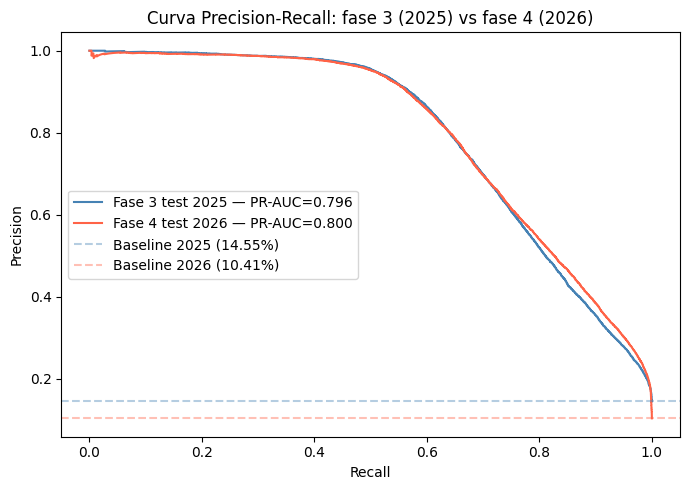

In [11]:
# Curvas PR comparadas
_, y_prob_f3, _ = evaluar_test(modelo_f3, X_test_f3, y_test_f3)
p3, r3, _ = precision_recall_curve(y_test_f3, y_prob_f3)
p4, r4, _ = precision_recall_curve(y_test_f4, y_prob_f4)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(r3, p3, color='steelblue', label=f"Fase 3 test 2025 — PR-AUC={metricas_f3['pr_auc_test']:.3f}")
ax.plot(r4, p4, color='tomato',    label=f"Fase 4 test 2026 — PR-AUC={metricas_f4['pr_auc_test']:.3f}")
ax.axhline(y_test_f3.mean(), color='steelblue', linestyle='--', alpha=0.4, label=f'Baseline 2025 ({y_test_f3.mean():.2%})')
ax.axhline(y_test_f4.mean(), color='tomato',    linestyle='--', alpha=0.4, label=f'Baseline 2026 ({y_test_f4.mean():.2%})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall: fase 3 (2025) vs fase 4 (2026)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Análisis de la variable objetivo

Se compara la prevalencia de alertas (`alert_in_next_15m`) entre 2025 completo y 2026.

In [12]:
prev_2025 = df_2025[TARGET].mean() * 100
prev_2026 = df_2026[TARGET].mean() * 100

print('=== Prevalencia de alertas (% positivos) ===')
print(f'  2025 (train completo): {prev_2025:.2f}%')
print(f'  2026 (nuevos datos):   {prev_2026:.2f}%')
print(f'  Δ prevalencia:         {prev_2026 - prev_2025:+.2f} pp')

=== Prevalencia de alertas (% positivos) ===
  2025 (train completo): 14.45%
  2026 (nuevos datos):   10.41%
  Δ prevalencia:         -4.04 pp


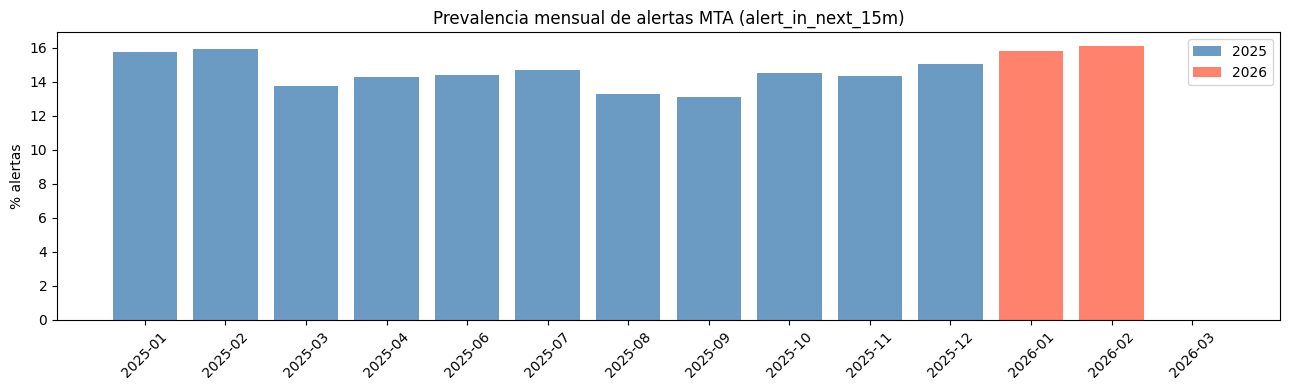

In [13]:
df_2025['_mes'] = pd.to_datetime(df_2025['merge_time']).dt.to_period('M')
df_2026['_mes'] = pd.to_datetime(df_2026['merge_time']).dt.to_period('M')

prev_mes_2025 = df_2025.groupby('_mes')[TARGET].mean() * 100
prev_mes_2026 = df_2026.groupby('_mes')[TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar([str(m) for m in prev_mes_2025.index], prev_mes_2025.values,
       color='steelblue', alpha=0.8, label='2025')
ax.bar([str(m) for m in prev_mes_2026.index], prev_mes_2026.values,
       color='tomato', alpha=0.8, label='2026')
ax.set_ylabel('% alertas')
ax.set_title('Prevalencia mensual de alertas MTA (alert_in_next_15m)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Análisis de las 3 variables más importantes

Se identifican las 3 features con mayor importancia en el modelo de fase 4 y se compara
su distribución entre 2025 (train) y 2026 (nuevos datos).

In [14]:
imp = pd.DataFrame({
    'feature':    feats,
    'importance': modelo_f4.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('=== Feature importance (gain) ===')
print(imp.head(10).to_string(index=False))

top3 = imp['feature'].iloc[:3].tolist()
print(f'\nTop 3: {top3}')

=== Feature importance (gain) ===
                      feature  importance
seg_desde_ultima_alerta_linea    0.364911
                  num_updates    0.097523
                     route_id    0.059774
                   is_weekend    0.038945
                     hour_sin    0.036050
            match_key_nunique    0.033104
           paradas_retrasadas    0.031918
           headway_mean_linea    0.027997
       pct_paradas_retrasadas    0.027894
               is_unscheduled    0.025585

Top 3: ['seg_desde_ultima_alerta_linea', 'num_updates', 'route_id']


In [15]:
print('=== Distribution shift en las 3 features más importantes ===')
print(f'{"Feature":<35} {"Media 2025":>15} {"Media 2026":>15} {"Δ %":>8}')
print('-' * 76)
for feat in top3:
    if feat not in df_2025.columns or feat not in df_2026.columns:
        print(f'{feat:<35} {"N/A":>15} {"N/A":>15} {"N/A":>8}')
        continue
    if not pd.api.types.is_numeric_dtype(df_2025[feat]):
        print(f'{feat:<35} {"(categórica)":>15} {"(categórica)":>15} {"N/A":>8}')
        continue
    m25 = df_2025[feat].mean()
    m26 = df_2026[feat].mean()
    delta_pct = (m26 - m25) / abs(m25) * 100 if m25 != 0 else float('nan')
    print(f'{feat:<35} {m25:>15.3f} {m26:>15.3f} {delta_pct:>+8.1f}%')

=== Distribution shift en las 3 features más importantes ===
Feature                                  Media 2025      Media 2026      Δ %
----------------------------------------------------------------------------
seg_desde_ultima_alerta_linea             97577.805      537543.375   +450.9%
num_updates                                   2.854         216.899  +7499.7%
route_id                               (categórica)    (categórica)      N/A


### Interpretación del distribution shift

**`seg_desde_ultima_alerta_linea` (+450.9%)**

Esta feature mide los segundos transcurridos desde la última alerta registrada
en el dataset para cada línea (rolling). El pipeline rellena con `999999` los
casos en que no existe ninguna alerta previa (NaN).

El diagnóstico muestra que en marzo 2026 el 12.2% de las filas tienen valor
`999999` (frente al 1.6% en enero), pero la mayor parte del shift **no** viene
de esos NaN. La causa real es que los datos de alertas MTA de marzo 2026 no
estaban publicados en data.ny.gov en el momento de extracción del parquet.Digamos que de todos los diferentes datos
que tenemos solo faltan las alertas de marzo 2026, se ahí estas anomalías en las top 3 features.
Como consecuencia, el pipeline no puede registrar alertas nuevas en marzo y la
feature sigue acumulando segundos desde la última alerta de febrero, generando
valores legítimos pero artificialmente grandes (del orden de millones de
segundos, equivalentes a semanas). Incluso excluyendo los 999999, la media en
2026 es de 120,427 s (~33 h) frente a 97,578 s (~27 h) en 2025.

**`num_updates` (+7499.7%)**

El salto de 2.85 → 216.9 actualizaciones por ventana de 30 min es demasiado
extremo para explicarse solo por cambios operacionales. Las causas más probables
son: (1) la MTA aumentó significativamente la frecuencia de publicación de su
feed GTFS-RT en 2026, de modo que cada ventana captura muchos más registros
brutos; o (2) el parquet de 2026 fue generado con una lógica de agregación
diferente a la de 2025, contabilizando más filas por intervalo.

**Conclusión**

Ambos shifts reflejan principalmente **problemas de homogeneidad entre los
datasets de 2025 y 2026**, no cambios reales en el comportamiento del metro.
Los datos de 2026 están alterados especialmente por la ausencia de datos alertas en
marzo ya que solo han sido publicados enero y febrero hasta el momento, lo que afecta tanto a las features (rolling inflado) como al target
(`alert_in_next_15m = 0` para todas las filas de ese mes). Esto limita la
validez de la comparación directa entre periodos.

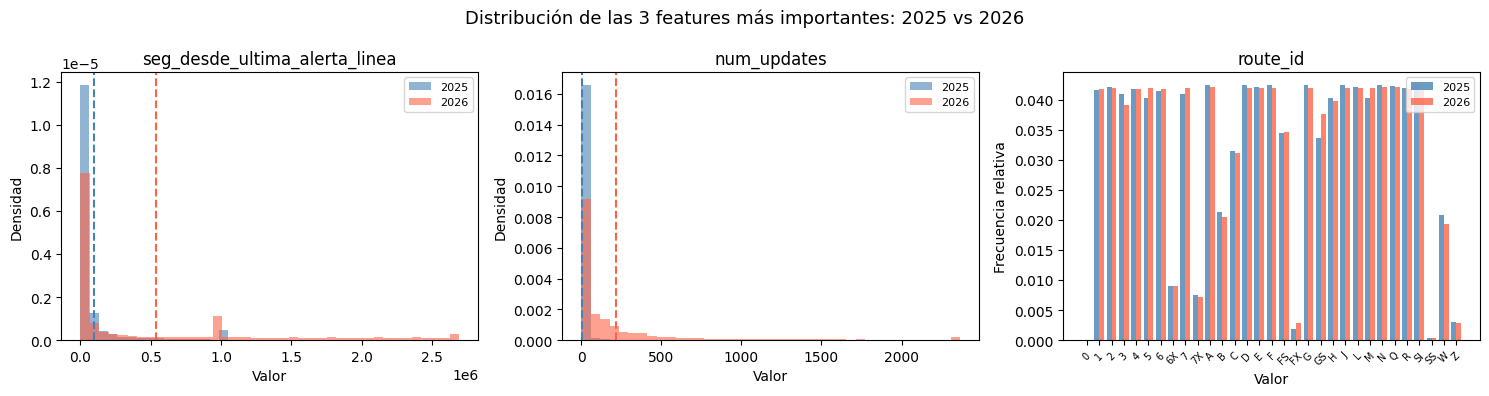

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, top3):
    if feat not in df_2025.columns or feat not in df_2026.columns:
        ax.set_title(f'{feat}\n(no disponible)')
        continue

    s25 = df_2025[feat].dropna()
    s26 = df_2026[feat].dropna()

    if not pd.api.types.is_numeric_dtype(s25):
        freq25 = s25.value_counts(normalize=True).sort_index()
        freq26 = s26.value_counts(normalize=True).sort_index()
        idx = sorted(set(freq25.index) | set(freq26.index))
        x = np.arange(len(idx))
        ax.bar(x - 0.2, [freq25.get(i, 0) for i in idx], 0.4, color='steelblue', alpha=0.8, label='2025')
        ax.bar(x + 0.2, [freq26.get(i, 0) for i in idx], 0.4, color='tomato',    alpha=0.8, label='2026')
        ax.set_xticks(x)
        ax.set_xticklabels(idx, rotation=45, fontsize=7)
        ax.set_ylabel('Frecuencia relativa')
    else:
        p99 = max(s25.quantile(0.99), s26.quantile(0.99))
        ax.hist(s25.clip(upper=p99), bins=40, alpha=0.6, color='steelblue', label='2025', density=True)
        ax.hist(s26.clip(upper=p99), bins=40, alpha=0.6, color='tomato',    label='2026', density=True)
        ax.axvline(s25.mean(), color='steelblue', linestyle='--', linewidth=1.5)
        ax.axvline(s26.mean(), color='tomato',    linestyle='--', linewidth=1.5)
        ax.set_ylabel('Densidad')

    ax.set_title(feat)
    ax.set_xlabel('Valor')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de las 3 features más importantes: 2025 vs 2026', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Rendimiento por línea

In [17]:
resultados = []
for linea in sorted(df_2026['route_id'].unique()):
    mask = df_2026['route_id'] == linea
    if mask.sum() == 0:
        continue
    y_seg    = y_test_f4[mask]
    pred_seg = (modelo_f4.predict_proba(X_test_f4[mask])[:, 1] >= metricas_f4['threshold_opt']).astype(int)
    resultados.append({
        'Linea':          linea,
        'Muestras':       int(mask.sum()),
        'Alertas_reales': int(y_seg.sum()),
        'Prevalencia_%':  round(y_seg.mean() * 100, 1),
        'F1':             round(f1_score(y_seg, pred_seg, zero_division=0), 4),
    })

df_lineas = pd.DataFrame(resultados).sort_values('F1', ascending=False)
print(df_lineas.to_string(index=False))

Linea  Muestras  Alertas_reales  Prevalencia_%     F1
    A      8631            1814           21.0 0.8068
    N      8623            1367           15.9 0.7806
    F      8614            1530           17.8 0.7706
    D      8611            1516           17.6 0.7603
    Q      8617            1324           15.4 0.7494
    B      4195             681           16.2 0.7386
    W      3966             359            9.1 0.7380
    2      8614            1458           16.9 0.7191
    C      6373             645           10.1 0.7178
    R      8562            1034           12.1 0.7121
   SI      8552              96            1.1 0.7033
    E      8594             994           11.6 0.6989
    J      8608             617            7.2 0.6962
    6      8574            1227           14.3 0.6804
    4      8574            1285           15.0 0.6776
    5      8589            1027           12.0 0.6663
    M      8601             604            7.0 0.6585
    3      8035             

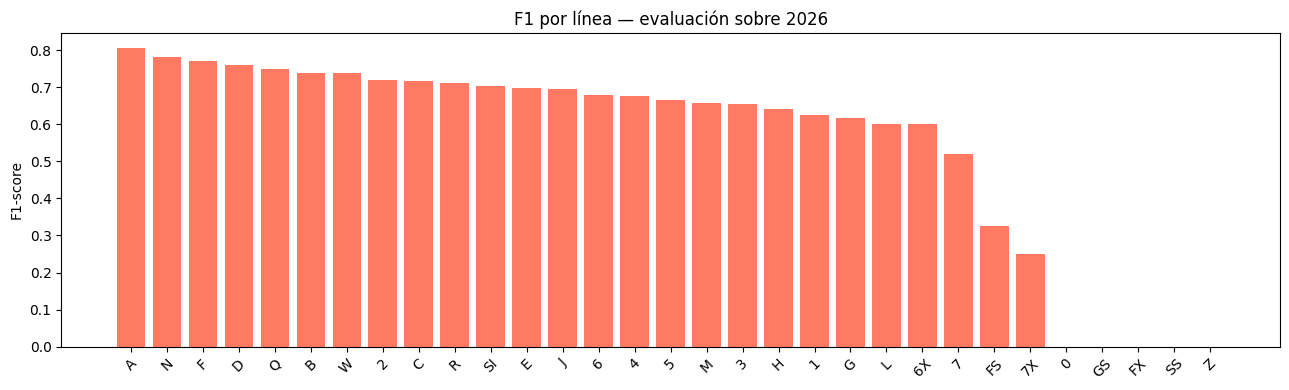

In [18]:
fig, ax = plt.subplots(figsize=(13, 4))
df_plot = df_lineas.sort_values('F1', ascending=False)
ax.bar(df_plot['Linea'], df_plot['F1'], color='tomato', alpha=0.85)
ax.set_ylabel('F1-score')
ax.set_title('F1 por línea — evaluación sobre 2026')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Conclusiones

El modelo reentrenado con todos los datos de 2025 y evaluado sobre los nuevos
datos de enero-marzo 2026 obtiene un **PR-AUC de 0.7997**, frente al **0.7956**
obtenido en el test de la fase anterior (Δ = **+0.0041**). El F1 se mantiene
prácticamente idéntico (0.7119 → 0.7118) y el ROC-AUC mejora de 0.9222 a
0.9513. **No se observa degradación del modelo**: la capacidad predictiva se
mantiene estable al generalizar sobre datos nuevos de 2026.

La prevalencia de alertas desciende. Este descendo no refleja un cambio real, 
**los datos de alertas MTA de marzo 2026 no estaban publicados en data.ny.gov**
Como consecuencia, todas las filas de marzo tienen `alert_in_next_15m = 0`

Las tres 'features' con mayor importancia en el modelo son:
- 'segs_desde_ultima_alerta_linea'
- 'num_updates'
- 'route_id'

Las dos features numéricas más importantes presentan shifts pronunciados en 2026: seg_desde_ultima_alerta_linea aumenta considerablemente porque la ausencia de alertas en marzo hace que el pipeline acumule días sin resetear el contador, y num_updates se dispara un +7499.7% por diferencias en la frecuencia del feed GTFS-RT o en la agregación del parquet de 2026. La distribución de route_id permanece estable entre ambos periodos, sin aparición de líneas nuevas relevantes.

Por otro lado, las líneas con mejor F1-score son la A,N y F. Todas estast con gran volumen de muestras. 

En definitiva las anomalías detectadas son atribuibles principalmente a problemas de calidad y completitud de los datos de 
2026 de alertas y no a una degradación real considerable del modelo.
